In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# 1. Getting data ready
### Three main things we have to do
1. split the data into features and labels (usually X and Y)
2. Filling (also called imputing) or disregarding missing values
3. converting non-numerical values to numerical values (also called feature encoding)

In [2]:
heart_disease = pd.read_csv("./data/heart-disease.csv")
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
# this is features
X = heart_disease.drop("target", axis=1)
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


In [4]:
# this is labels
Y = heart_disease.target
Y.head()

0    1
1    1
2    1
3    1
4    1
Name: target, dtype: int64

In [5]:
# split the data into training and test sets
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2)

In [6]:
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((242, 13), (61, 13), (242,), (61,))

### Clean Data -> Transform Data -> Reduce Data

### 1.1 Make sure it is all numerical

In [7]:
car_sales = pd.read_csv("./data/car-sales-extended.csv")
car_sales.head()

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431,4,15323
1,BMW,Blue,192714,5,19943
2,Honda,White,84714,4,28343
3,Toyota,White,154365,4,13434
4,Nissan,Blue,181577,3,14043


In [8]:
car_sales.dtypes

Make               str
Colour             str
Odometer (KM)    int64
Doors            int64
Price            int64
dtype: object

In [9]:
# Split the data
X = car_sales.drop("Price",axis=1)
Y = car_sales.Price

# split into training and test
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2)

In [10]:
# from sklearn.ensemble import RandomForestRegressor

# model = RandomForestRegressor()
# model.fit(X_train,Y_train)
# model.score(X_test,Y_test)

# this will give an error

### ML models cant deal with strings, it only knows numbers

In [11]:
# turn categories into numbers
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ["Make","Colour","Doors"] # doors are either 2,3,4 so this can also be treated as categories
one_hot = OneHotEncoder()
transformer = ColumnTransformer([("one_hot",one_hot,categorical_features)],remainder="passthrough")

transformed_X = transformer.fit_transform(X)
transformed_X

array([[0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 3.54310e+04],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        1.00000e+00, 1.92714e+05],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 8.47140e+04],
       ...,
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 6.66040e+04],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 2.15883e+05],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 2.48360e+05]], shape=(1000, 13))

In [12]:
pd.DataFrame(transformed_X)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,35431.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,192714.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,84714.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,154365.0
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,181577.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,35820.0
996,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,155144.0
997,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,66604.0
998,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,215883.0


In [13]:
X.head()

,Make,Colour,Odometer (KM),Doors
0,Honda,White,35431,4
1,BMW,Blue,192714,5
2,Honda,White,84714,4
3,Toyota,White,154365,4
4,Nissan,Blue,181577,3


<img src="https://github.com/kunal-sharma-2803/AI-ML/blob/main/sample_project1/one_hot_encoding.jpg?raw=1">

In [14]:
# another way
dummeies = pd.get_dummies(car_sales[["Make","Colour","Doors"]])
dummeies

,Doors,Make_BMW,Make_Honda,Make_Nissan,Make_Toyota,Colour_Black,Colour_Blue,Colour_Green,Colour_Red,Colour_White
0,4,False,True,False,False,False,False,False,False,True
1,5,True,False,False,False,False,True,False,False,False
2,4,False,True,False,False,False,False,False,False,True
3,4,False,False,False,True,False,False,False,False,True
4,3,False,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...
995,4,False,False,False,True,True,False,False,False,False
996,3,False,False,True,False,False,False,False,False,True
997,4,False,False,True,False,False,True,False,False,False
998,4,False,True,False,False,False,False,False,False,True


In [15]:
np.random.seed(42)
from sklearn.ensemble import RandomForestRegressor

Y = car_sales.Price

X_train,X_test,Y_train,Y_test = train_test_split(transformed_X,Y,test_size=0.2)

model = RandomForestRegressor()
model.fit(X_train,Y_train)

model.score(X_test,Y_test)

0.3235867221569877

### 1.2 Dealing with missing values
1. Fill them with some value (aka imputation)
2. Remove the samples with missing data altogether

In [16]:
car_sales_missing = pd.read_csv("./data/car-sales-extended-missing-data.csv")
car_sales_missing.tail()

,Make,Colour,Odometer (KM),Doors,Price
995,Toyota,Black,35820.0,4.0,32042.0
996,NaN,White,155144.0,3.0,5716.0
997,Nissan,Blue,66604.0,4.0,31570.0
998,Honda,White,215883.0,4.0,4001.0
999,Toyota,Blue,248360.0,4.0,12732.0


In [17]:
car_sales_missing.isna().sum()

Make             49
Colour           50
Odometer (KM)    50
Doors            50
Price            50
dtype: int64

In [18]:
## convert data to numbers
X = car_sales_missing.drop("Price",axis=1)
Y = car_sales_missing.Price

#### we have to fix the missing data first
### option 1 :- using pandas


In [19]:
# Fill the "Make" column
car_sales_missing.fillna({"Make" : "missing"},inplace=True)
# Fill the "Colour" column
car_sales_missing.fillna({"Colour" : "missing" },inplace=True)
# Fill the "Odometer" column
car_sales_missing.fillna({ "Odometer (KM)" : car_sales_missing["Odometer (KM)"].mean() },inplace=True)
# Fill the "Doors" column
car_sales_missing.fillna({"Doors" : 4},inplace=True)

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0
2,Honda,White,84714.0,4.0,28343.0
3,Toyota,White,154365.0,4.0,13434.0
4,Nissan,Blue,181577.0,3.0,14043.0
...,...,...,...,...,...
995,Toyota,Black,35820.0,4.0,32042.0
996,missing,White,155144.0,3.0,5716.0
997,Nissan,Blue,66604.0,4.0,31570.0
998,Honda,White,215883.0,4.0,4001.0


In [20]:
car_sales_missing.isna().sum()

Make              0
Colour            0
Odometer (KM)     0
Doors             0
Price            50
dtype: int64

In [21]:
# as we are predicting the price itself there is no point filling it so we remove it
car_sales_missing.dropna(inplace=True)

In [22]:
car_sales_missing.isna().sum()

Make             0
Colour           0
Odometer (KM)    0
Doors            0
Price            0
dtype: int64

In [23]:
## convert data to numbers
X = car_sales_missing.drop("Price",axis=1)
Y = car_sales_missing.Price

In [24]:
# turn categories into numbers
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ["Make","Colour","Doors"] # doors are either 2,3,4 so this can also be treated as categories
one_hot = OneHotEncoder()
transformer = ColumnTransformer([("one_hot",one_hot,categorical_features)],remainder="passthrough")

transformed_X = transformer.fit_transform(X)
transformed_X.toarray()

array([[0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 3.54310e+04],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        1.00000e+00, 1.92714e+05],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 8.47140e+04],
       ...,
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 6.66040e+04],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 2.15883e+05],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 2.48360e+05]], shape=(950, 15))

### Option 2 :- using SciKit-learn

In [25]:
car_sales_missing = pd.read_csv("./data/car-sales-extended-missing-data.csv")
car_sales_missing.tail()

,Make,Colour,Odometer (KM),Doors,Price
995,Toyota,Black,35820.0,4.0,32042.0
996,NaN,White,155144.0,3.0,5716.0
997,Nissan,Blue,66604.0,4.0,31570.0
998,Honda,White,215883.0,4.0,4001.0
999,Toyota,Blue,248360.0,4.0,12732.0


In [26]:
car_sales_missing.isna().sum()

Make             49
Colour           50
Odometer (KM)    50
Doors            50
Price            50
dtype: int64

In [27]:
# drop from price first
car_sales_missing.dropna(subset=["Price"],inplace=True)
car_sales_missing.isna().sum()

Make             47
Colour           46
Odometer (KM)    48
Doors            47
Price             0
dtype: int64

In [28]:
X = car_sales_missing.drop("Price",axis=1)
Y = car_sales_missing.Price

In [29]:
# Fill missing values
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

categorical_imputer = SimpleImputer(strategy="constant", fill_value="missing")
door_imputer = SimpleImputer(strategy="constant",fill_value=4)
num_imputer = SimpleImputer(strategy="mean")

categorical_features = ["Make","Colour"]
door_features = ["Doors"]
num_featuers = ["Odometer (KM)"]

imputer = ColumnTransformer([("categorical_imputer",categorical_imputer,categorical_features),
                             ("door_imputer",door_imputer,door_features),
                             ("num_imputer",num_imputer,num_featuers)]) # name,imputer,columns

filled_X = imputer.fit_transform(X)

In [30]:
filled_X

array([['Honda', 'White', 4.0, 35431.0],
       ['BMW', 'Blue', 5.0, 192714.0],
       ['Honda', 'White', 4.0, 84714.0],
       ...,
       ['Nissan', 'Blue', 4.0, 66604.0],
       ['Honda', 'White', 4.0, 215883.0],
       ['Toyota', 'Blue', 4.0, 248360.0]], shape=(950, 4), dtype=object)

In [31]:
car_sales_filled = pd.DataFrame(filled_X,columns=["Make","Colour","Doors","Odometer (KM)"])
car_sales_filled.head()

,Make,Colour,Doors,Odometer (KM)
0,Honda,White,4.0,35431.0
1,BMW,Blue,5.0,192714.0
2,Honda,White,4.0,84714.0
3,Toyota,White,4.0,154365.0
4,Nissan,Blue,3.0,181577.0


In [32]:
car_sales_filled.isna().sum()

Make             0
Colour           0
Doors            0
Odometer (KM)    0
dtype: int64

In [33]:
X = car_sales_filled

In [34]:
# turn categories into numbers
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ["Make","Colour","Doors"] # doors are either 2,3,4 so this can also be treated as categories
one_hot = OneHotEncoder()
transformer = ColumnTransformer([("one_hot",one_hot,categorical_features)],remainder="passthrough")

transformed_X = transformer.fit_transform(X)
transformed_X.toarray()

array([[0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 3.54310e+04],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        1.00000e+00, 1.92714e+05],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 8.47140e+04],
       ...,
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 6.66040e+04],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 2.15883e+05],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 2.48360e+05]], shape=(950, 15))

In [35]:
# fit a model
np.random.seed(42)
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test = train_test_split(transformed_X,Y,test_size=0.2)

model = RandomForestRegressor()
model.fit(X_train,Y_train)
model.score(X_test,Y_test)

0.21990196728583944

#### This performs worse because
1. it has less samples
2. the data is filled and not real

# 2. Choosing the right estimator/algorithm for our problem

#### SciKit-learn uses estimator as another term for out ML model or algorithm

- Classification :- predicting weather a sample is one thing or another
- Regression :- predicting a number

google :- sklearn ml map

### 2.1 Picking a ML model for a regression Problem

In [36]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()
diabetes

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]], shape=(442, 10)),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142.

In [37]:
diabetes_df = pd.DataFrame(diabetes["data"],columns=diabetes["feature_names"])
diabetes_df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [38]:
diabetes_df["target"] = pd.Series(diabetes["target"])
diabetes_df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [39]:
# how many samples
len(diabetes_df)

442

In [40]:
# lets try ridge regeression, idea from ml map
from sklearn.linear_model import Ridge

# so results can be reproduced
np.random.seed(42)

# get the data
X = diabetes_df.drop("target",axis=1)
Y = diabetes_df.target

# split the data
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2)

# fit to model :- asking model to find patterns
model = Ridge()
model.fit(X_train,Y_train)

# test our model
model.score(X_test,Y_test)

0.41915292635986545

this is not a good score so Ridge might not be working so go to the map again to check if something else can be done

In [41]:
# try random forest from ensemble
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)

model = RandomForestRegressor()
model.fit(X_train,Y_train)

model.score(X_test,Y_test)

0.4428225673999313

### 2.2 Picking a ML model for a classification Problem

In [42]:
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [43]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split

np.random.seed(42)

X = heart_disease.drop("target",axis = 1)
Y = heart_disease.target

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,train_size=0.2)

model = LinearSVC()
model.fit(X_train,Y_train)

model.score(X_test,Y_test)

0.7695473251028807

In [44]:
# this is low so go to another model

from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

X = heart_disease.drop("target",axis = 1)
Y = heart_disease.target

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,train_size=0.2)

model = RandomForestClassifier()
model.fit(X_train,Y_train)

model.score(X_test,Y_test)

0.831275720164609

#### Hint :-
1. if you have structured data use ensemble methods
2. if you have unstructured data then use deep learning or transfer learning

## 3. Fit the model/algo on our data to make predictions

### 3.1 Fitting the model to our data

In [45]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


In [46]:
Y.head()

0    1
1    1
2    1
3    1
4    1
Name: target, dtype: int64

Fit means the model looks at "X" and tries to find patterns which lead to "Y"  
When we pass the testing data, these patterns are used to find patterns

### 3.2 Make predictions using a ml model

#### use a trained model to make predictions

There are 2 main ways
1. `predict`
2. `predict_proba`

In [47]:
# model.predict(np.array([1,2,8,6]))

# this will give error

In [48]:
# the above doesnt work because, the format of training data and test data has to be the same

model.predict(X_test)

array([0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1,
       1])

In [49]:
np.array(Y_test)

array([0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1,
       1])

In [50]:
# comparing the prediction to the truths
Y_preds = model.predict(X_test)
np.mean(Y_preds == Y_test)

np.float64(0.831275720164609)

In [51]:
model.score(X_test,Y_test)
# this does the smae thing as above

0.831275720164609

In [52]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_test,Y_preds)
# this also does the same thing

0.831275720164609

In [53]:
# Making predictions using predict_proba

# predict_proba() returns probabilities of a classification label
model.predict_proba(X_test[:5])
# returns the probability of a label being true
# [prob. of 0, prob. of 1]
# if target column had [0,1,2,.....,n] as values then the prob would also have [0,1,2....n]

array([[0.93, 0.07],
       [0.42, 0.58],
       [0.33, 0.67],
       [0.88, 0.12],
       [0.23, 0.77]])

In [54]:
model.predict(X_test[:5])

array([0, 1, 1, 0, 1])

## 4. Evaluating a ML model
1. Estimator `score` method
2. the `scoring` parameter
3. problem specific metric functions

### 4.1 Evaluating a model with `score`

In [55]:
model.score(X_test,Y_test)
# the score method for each type of model has a different metric, check via shift+tab that what exactly is the score doing

0.831275720164609

### 4.2 Evaluating using `scoring` parameter

In [56]:
from sklearn.model_selection import cross_val_score

from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

X = heart_disease.drop("target",axis = 1)
Y = heart_disease.target

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,train_size=0.2)

model = RandomForestClassifier()
model.fit(X_train,Y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [57]:
model.score(X_test,Y_test)

0.831275720164609

In [58]:
np.random.seed(42)
cross_val_score(model,X,Y)
# this means cross validation score

array([0.81967213, 0.90163934, 0.83606557, 0.78333333, 0.78333333])

<img src="https://github.com/kunal-sharma-2803/AI-ML/blob/main/sample_project1/images/cross-validation.jpg?raw=1">

In [59]:
np.random.seed(42)
cross_val_score(model,X,Y,cv=10)
# here cv means how many fold cross-validation do we want, 5 is just the default

array([0.80645161, 0.80645161, 0.87096774, 0.9       , 0.9       ,
       0.83333333, 0.73333333, 0.83333333, 0.73333333, 0.76666667])

In [60]:
model_single_score = model.score(X_test,Y_test)
model_cross_val_score = np.mean(cross_val_score(model,X,Y))

model_single_score, model_cross_val_score

(0.831275720164609, np.float64(0.8116939890710382))

In [61]:
# cross_val should be preffered over score
np.random.seed(42)
cross_val_score(model,X,Y,scoring=None)
# this none (by default) means cross_val will use the default evaluation metric of the mdoel, which is given by .score method

array([0.81967213, 0.90163934, 0.83606557, 0.78333333, 0.78333333])

### 4.2.1 Classification model evaluations metrics
1. accuracy
2. area under ROC curve
3. confusion matrix
4. classification report

`Accuracy`

In [62]:
np.random.seed(42)
cross_val_score = cross_val_score(model,X,Y)

In [63]:
np.mean(cross_val_score)

np.float64(0.8248087431693989)

`ROC Curve`

##### ROC :- reciever operating characteristics curve
##### AUC :- area under curve

ROC curves are a comparison of a model's true +ve rate (tpr) versus a model false +ve rate (fpr)  
* True +ve :- model predicts 1 when truth is 1  
* False +ve :- model predicts 1 when truth is 0  
* True -ve :- model predicts 0 when truth is 0  
* False -ve :- model predicts 0 when truth is 1  


In [64]:
Y_prob = model.predict_proba(X_test)

In [65]:
Y_prob[:10]

array([[0.93, 0.07],
       [0.42, 0.58],
       [0.33, 0.67],
       [0.88, 0.12],
       [0.23, 0.77],
       [0.23, 0.77],
       [0.6 , 0.4 ],
       [0.96, 0.04],
       [0.91, 0.09],
       [0.41, 0.59]])

In [66]:
Y_prob_positive = Y_prob[:, 1]
Y_prob_positive[:10]

array([0.07, 0.58, 0.67, 0.12, 0.77, 0.77, 0.4 , 0.04, 0.09, 0.59])

In [67]:
# calculate fpr,tpr,thresholds
from sklearn.metrics import roc_curve
fpr,tpr,thresholds = roc_curve(Y_test,Y_prob_positive)

In [68]:
# check the false +ve rates
fpr

array([0.        , 0.        , 0.        , 0.00917431, 0.00917431,
       0.00917431, 0.00917431, 0.00917431, 0.00917431, 0.00917431,
       0.00917431, 0.01834862, 0.01834862, 0.01834862, 0.01834862,
       0.02752294, 0.03669725, 0.03669725, 0.04587156, 0.04587156,
       0.05504587, 0.0733945 , 0.08256881, 0.10091743, 0.10091743,
       0.10091743, 0.10091743, 0.11009174, 0.11009174, 0.11009174,
       0.12844037, 0.12844037, 0.13761468, 0.18348624, 0.19266055,
       0.20183486, 0.20183486, 0.21100917, 0.22018349, 0.22018349,
       0.24770642, 0.26605505, 0.28440367, 0.30275229, 0.32110092,
       0.33944954, 0.35779817, 0.36697248, 0.3853211 , 0.3853211 ,
       0.40366972, 0.42201835, 0.4587156 , 0.46788991, 0.48623853,
       0.50458716, 0.53211009, 0.55045872, 0.55963303, 0.57798165,
       0.59633028, 0.63302752, 0.68807339, 0.69724771, 0.71559633,
       0.7706422 , 0.80733945, 0.83486239, 0.88073394, 0.93577982,
       0.96330275, 0.98165138, 1.        ])

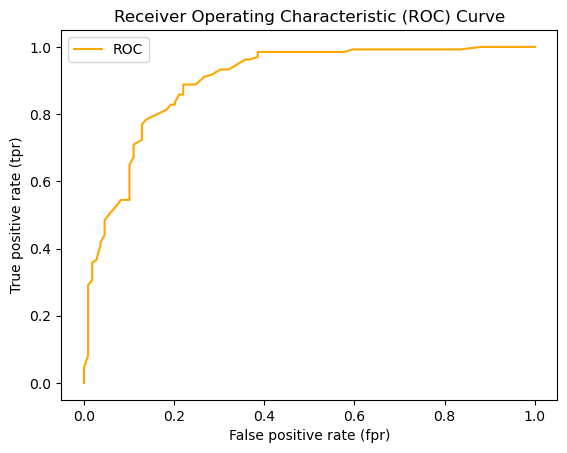

In [69]:
# create a function for processing ROC curves
import matplotlib.pyplot as plt

def plot_roc_curve(fpr, tpr):

    # Plot ROC Curve
    plt.plot(fpr,tpr,color="orange",label="ROC")

    # Plot the line with no predictive power (baseline)
    #plt.plot([0,1], [0,1], color="darkblue", linestyle="--", label="Guessing")

    # Customise the plot
    plt.xlabel("False positive rate (fpr)")
    plt.ylabel("True positive rate (tpr)")
    plt.title("Receiver Operating Characteristic (ROC) Curve")
    plt.legend()
    plt.show()

plot_roc_curve(fpr,tpr)

In [70]:
from sklearn.metrics import roc_auc_score

roc_auc_score(Y_test,Y_prob_positive)

0.899561823907983

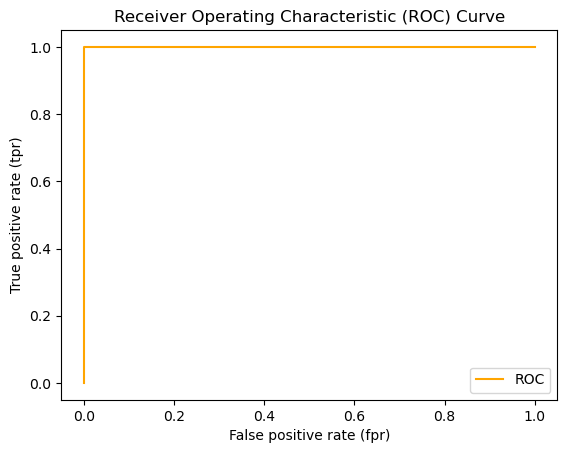

In [71]:
# Plot perfect roc curve

fpr,tpr,threshold = roc_curve(Y_test,Y_test)
plot_roc_curve(fpr,tpr)

In [72]:
roc_auc_score(Y_test,Y_test)

1.0

### Confusion Matrix

A confusion matrix is a quick way to compare the labels a model predicts and the actual labels it was supossed to predict  
In essence giving you an idea where the model is getting confused  

In [73]:
from sklearn.metrics import confusion_matrix

Y_preds = model.predict(X_test)

confusion_matrix(Y_test,Y_preds)

array([[ 80,  29],
       [ 12, 122]])

In [74]:
# Visualise confusion matrix with pd.crosstab()

pd.crosstab(Y_test,Y_preds,rownames=["Actual Labels"],colnames=["Predictred Lables"])

Predictred Lables,0,1
Actual Labels,,
0,80,29
1,12,122


In [75]:
len(Y_preds)

243

In [76]:
80+12+29+122

243

In [77]:
# Bonus :- installing a module to environment from the notebook

# import sys
# !conda install --yes --prefix {sys.prefix} seaborn

<Axes: >

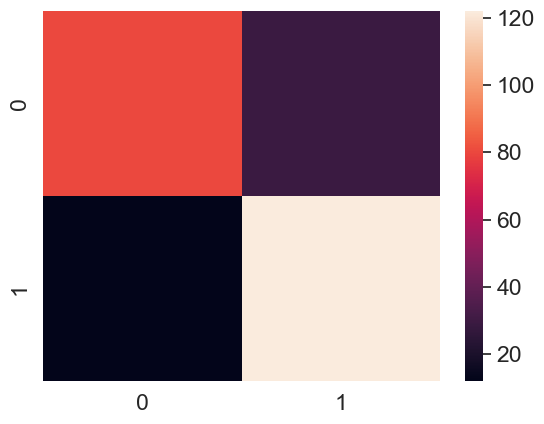

In [78]:
# Make our confusion matrix more visual with seaborn heatmap

import seaborn as sns

sns.set(font_scale=1.5)

conf_mat = confusion_matrix(Y_test,Y_preds)

sns.heatmap(conf_mat)

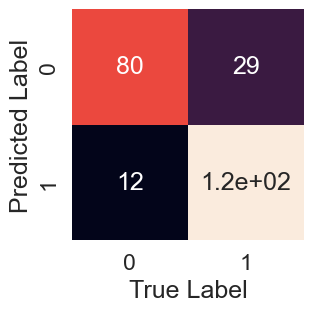

In [79]:
def plot_conf_map(conf_mat):

    fig,ax = plt.subplots(figsize=(3,3))
    ax = sns.heatmap(conf_mat,annot=True,cbar=False)

    plt.xlabel("True Label")
    plt.ylabel("Predicted Label")

plot_conf_map(conf_mat)

### Clasification report :-
Collecteion of different evaluation metrics

In [80]:
from sklearn.metrics import classification_report

print(classification_report(Y_test,Y_preds))

              precision    recall  f1-score   support

           0       0.87      0.73      0.80       109
           1       0.81      0.91      0.86       134

    accuracy                           0.83       243
   macro avg       0.84      0.82      0.83       243
weighted avg       0.84      0.83      0.83       243



- Precision - Indicates the proportion of positive identifications (model predicted class 1) which were actually correct. A model which produces no false positives has a precision of 1.0.
- Recall - Indicates the proportion of actual positives which were correctly classified. A model which produces no false negatives has a recall of 1.0.
- F1 score - A combination of precision and recall. A perfect model achieves an F1 score of 1.0.
- Support - The number of samples each metric was calculated on.
- Accuracy - The accuracy of the model in decimal form. Perfect accuracy is equal to 1.0, in other words, getting the prediction right 100% of the time.
- Macro avg - Short for macro average, the average precision, recall and F1 score between classes. Macro avg doesn't take class imbalance into effect. So if you do have class imbalances (more examples of one class than another), you should pay attention to this.
- Weighted avg - Short for weighted average, the weighted average precision, recall and F1 score between classes. Weighted means each metric is calculated with respect to how many samples there are in each class. This metric will favour the majority class (e.g. it will give a high value when one class out performs another due to having more samples).

In [81]:
pd.DataFrame(classification_report(Y_test,Y_preds,output_dict=True))
# another way to visualise

,0,1,accuracy,macro avg,weighted avg
precision,0.869565,0.807947,0.831276,0.838756,0.835586
recall,0.733945,0.910448,0.831276,0.822196,0.831276
f1-score,0.796020,0.856140,0.831276,0.826080,0.829173
support,109.000000,134.000000,0.831276,243.000000,243.000000


In [82]:
# where classification report becomes valuable

disease_true = np.zeros(10000)
disease_true[0] = 1

disease_preds = np.zeros(10000) # lets say our model predicted every one as zero

pd.DataFrame(classification_report(disease_true,disease_preds,output_dict=True))

C:\Users\kunal\Desktop\AI_ML\sample_project1\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kunal\Desktop\AI_ML\sample_project1\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kunal\Desktop\AI_ML\sample_project1\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

,0.0,1.0,accuracy,macro avg,weighted avg
precision,0.99990,0.0,0.9999,0.499950,0.99980
recall,1.00000,0.0,0.9999,0.500000,0.99990
f1-score,0.99995,0.0,0.9999,0.499975,0.99985
support,9999.00000,1.0,0.9999,10000.000000,10000.00000


### 4.2.2 Regression model evaluation metrics

- R^2 (pronounced r-squared) or coefficient of determination - Compares your models predictions to the mean of the targets. Values can range from negative infinity (a very poor model) to 1. For example, if all your model does is predict the mean of the targets, its R^2 value would be 0. And if your model perfectly predicts a range of numbers it's R^2 value would be 1. Higher is better.
- Mean absolute error (MAE) - The average of the absolute differences between predictions and actual values. It gives you an idea of how wrong your predictions were. Lower is better.
- Mean squared error (MSE) - The average squared differences between predictions and actual values. Squaring the errors removes negative errors. It also amplifies outliers (samples which have larger errors). Lower is better.

In [83]:
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)

X = diabetes_df.drop("target",axis=1)
Y = diabetes_df.target

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,train_size=0.2)

model = RandomForestRegressor()
model.fit(X_train,Y_train)

model.score(X_test,Y_test)
# this gives us the R^2 by default

0.40046868300152927

In [84]:
from sklearn.metrics import r2_score

Y_test_mean = np.full(len(Y_test),Y_test.mean())

In [85]:
Y_test.mean()

np.float64(155.1949152542373)

In [86]:
Y_test_mean

array([155.19491525, 155.19491525, 155.19491525, 155.19491525,
       155.19491525, 155.19491525, 155.19491525, 155.19491525,
       155.19491525, 155.19491525, 155.19491525, 155.19491525,
       155.19491525, 155.19491525, 155.19491525, 155.19491525,
       155.19491525, 155.19491525, 155.19491525, 155.19491525,
       155.19491525, 155.19491525, 155.19491525, 155.19491525,
       155.19491525, 155.19491525, 155.19491525, 155.19491525,
       155.19491525, 155.19491525, 155.19491525, 155.19491525,
       155.19491525, 155.19491525, 155.19491525, 155.19491525,
       155.19491525, 155.19491525, 155.19491525, 155.19491525,
       155.19491525, 155.19491525, 155.19491525, 155.19491525,
       155.19491525, 155.19491525, 155.19491525, 155.19491525,
       155.19491525, 155.19491525, 155.19491525, 155.19491525,
       155.19491525, 155.19491525, 155.19491525, 155.19491525,
       155.19491525, 155.19491525, 155.19491525, 155.19491525,
       155.19491525, 155.19491525, 155.19491525, 155.19

In [87]:
r2_score(Y_test,Y_test_mean)

0.0

In [88]:
r2_score(Y_test,Y_test)

1.0

In [89]:
# mean absolute error (MAE)

from sklearn.metrics import mean_absolute_error

Y_preds = model.predict(X_test)

mae = mean_absolute_error(Y_test,Y_preds)
mae

48.69508474576271

In [90]:
df = pd.DataFrame(data={"actual values": Y_test, "predicted values": Y_preds})
df["differences"] = df["predicted values"] - df["actual values"]
df

,actual values,predicted values,differences
287,219.0,143.53,-75.47
211,70.0,163.02,93.02
72,202.0,143.51,-58.49
321,230.0,237.63,7.63
73,111.0,113.32,2.32
...,...,...,...
279,200.0,79.27,-120.73
382,132.0,185.68,53.68
337,91.0,192.76,101.76
236,67.0,192.39,125.39


In [91]:
# mean squared error

from sklearn.metrics import mean_squared_error

mse = mean_squared_error(Y_test,Y_preds)
mse

3577.944557062147

- R^2 is similar to accuracy. It gives you a quick indication of how well your model might be doing. Generally, the closer your R^2 value is to 1.0, the better the model. But it doesn't really tell exactly how wrong your model is in terms of how far off each prediction is.
- MAE gives a better indication of how far off each of your model's predictions are on average.
- As for MAE or MSE, because of the way MSE is calculated, squaring the differences between predicted values and actual values, it amplifies larger differences. Let's say we're predicting the value of houses (which we are).
- Pay more attention to MAE: When being $10,000 off is twice as bad as being $5,000 off.
- Pay more attention to MSE: When being $10,000 off is more than twice as bad as being $5,000 off.


### 4.2.3 Using the Scoring parameter

In [92]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

X = heart_disease.drop("target", axis=1)
Y = heart_disease.target

model = RandomForestClassifier()

In [93]:
# RandomForestClassifier by default uses accuracy in scoring parameter
np.random.seed(42)
cv_acc = cross_val_score(model,X,Y,cv=5)
cv_acc_mean = np.mean(cv_acc)
cv_acc_mean

np.float64(0.8248087431693989)

In [94]:
# Accuracy
np.random.seed(42)
cv_acc = cross_val_score(model,X,Y,cv=5,scoring="accuracy")
cv_acc_mean = np.mean(cv_acc)
cv_acc_mean

np.float64(0.8248087431693989)

In [95]:
# Precision
np.random.seed(42)
cv_acc = cross_val_score(model,X,Y,cv=5,scoring="precision")
cv_acc_mean = np.mean(cv_acc)
cv_acc_mean

np.float64(0.8329547346025924)

In [96]:
# Recall
np.random.seed(42)
cv_acc = cross_val_score(model,X,Y,cv=5,scoring="recall")
cv_acc_mean = np.mean(cv_acc)
cv_acc_mean

np.float64(0.8545454545454545)

In [97]:
# F1
np.random.seed(42)
cv_acc = cross_val_score(model,X,Y,cv=5,scoring="f1")
cv_acc_mean = np.mean(cv_acc)
cv_acc_mean

np.float64(0.8426854603423344)

For regression models

In [98]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)

X = diabetes_df.drop("target", axis=1)
Y = diabetes_df.target

model = RandomForestRegressor()

In [99]:
# RandomForestRegressor by default uses R^2
np.random.seed(42)
cv_acc = cross_val_score(model,X,Y,cv=5)
cv_acc_mean = np.mean(cv_acc)
cv_acc_mean

np.float64(0.411632501113053)

In [100]:
# R^2
np.random.seed(42)
cv_acc = cross_val_score(model,X,Y,cv=5,scoring="r2")
cv_acc_mean = np.mean(cv_acc)
cv_acc_mean

np.float64(0.411632501113053)

In [101]:
# Mean Absolute Error
np.random.seed(42)
cv_acc = cross_val_score(model,X,Y,cv=5,scoring="neg_mean_absolute_error")
cv_acc_mean = np.mean(cv_acc)
cv_acc_mean

np.float64(-47.64093998978549)

All scorer objects follow the convention that higher return values are better than lower return values, so we have to use "neg"

In [102]:
# Mean Squared Error
np.random.seed(42)
cv_acc = cross_val_score(model,X,Y,cv=5,scoring="neg_mean_squared_error")
cv_acc_mean = np.mean(cv_acc)
cv_acc_mean

np.float64(-3412.2200287206338)

### 4.3 Using different evaluation metrics as scikit-learn functions

classification evaluation examples

In [103]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

np.random.seed(42)

X = heart_disease.drop("target", axis=1)
Y = heart_disease.target

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train,Y_train)

Y_preds = model.predict(X_test)

# Evaluate the classifier
accuracy_score(Y_test,Y_preds), precision_score(Y_test,Y_preds), recall_score(Y_test,Y_preds), f1_score(Y_test,Y_preds)

(0.8524590163934426, 0.8484848484848485, 0.875, 0.8615384615384616)

regression evaluation functions

In [104]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

np.random.seed(42)

X = diabetes_df.drop("target", axis=1)
Y = diabetes_df.target

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2)

model = RandomForestRegressor()
model.fit(X_train,Y_train)

Y_preds = model.predict(X_test)

# Evaluate the classifier
r2_score(Y_test,Y_preds), mean_absolute_error(Y_test,Y_preds), mean_squared_error(Y_test,Y_preds)

(0.42417421495301266, 44.53921348314607, 3050.8123898876406)

## 5. Improving a model

First Prediction = baseline predictions
Frist Model = baseline Model

From a data perspective
- can we collect more data (the more data the better)
- can we improve our data

From a model perspective
- Can we use a better model
- Can we improve the current model

Parameters v/s Hyper-parameters
- Parameters = model finds these patterns in data  
- Hyper-parameters = settings on a model you can adjust to (potentially) improve its ability to find patterns

In [105]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

Three ways to adjust Hyper-parameters
1. By Hand
2. Randomly with `RandomSearchCV`
3. Exaustively with `GridSearchCV`

### 5.1 Tuning Hyperparameters by hand

we make 3 sets training, validation and test

In [106]:
def evaluate_preds(Y_true, Y_preds):
  accuracy = accuracy_score(Y_true, Y_preds)
  precision = precision_score(Y_true, Y_preds)
  recall = recall_score(Y_true, Y_preds)
  f1 = f1_score(Y_true, Y_preds)

  metric_dict = {"accuracy": round(accuracy, 2),"precision": round(precision, 2),"recall": round(recall, 2),"f1": round(f1, 2)}

  print(f"Acc: {accuracy * 100:.2f}%")
  print(f"Precision: {precision:.2f}")
  print(f"Recall: {recall:.2f}")
  print(f"F1 score: {f1:.2f}")

  return metric_dict


In [107]:
np.random.seed(42)

# shuffle the data
heart_disease_shuffled = heart_disease.sample(frac=1)

# split into X and Y
X = heart_disease_shuffled.drop("target", axis=1)
Y = heart_disease_shuffled.target

# split into train,validation,test split
train_split = round(0.7 * len(heart_disease_shuffled)) # 70% of the data
valid_split = round(train_split + 0.15 * len(heart_disease_shuffled)) # 15% of the data

X_train, Y_train = X[:train_split], Y[:train_split]
X_valid,Y_valid = X[train_split:valid_split], Y[train_split:valid_split]
X_test, Y_test = X[valid_split:], Y[valid_split:]

model = RandomForestClassifier()
model.fit(X_train,Y_train)

# baseline predictions
Y_preds = model.predict(X_valid)
baseline_metrics = evaluate_preds(Y_valid,Y_preds)
baseline_metrics

Acc: 82.22%
Precision: 0.81
Recall: 0.88
F1 score: 0.85


{'accuracy': 0.82, 'precision': 0.81, 'recall': 0.88, 'f1': 0.85}

In [108]:
model.get_params()
# look in the documentation for the definition of each of these

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [109]:
np.random.seed(42)

# create a second model on which we will change hyperparameters
model_2 = RandomForestClassifier(max_depth=3)
model_2.fit(X_train,Y_train)

# Make predictions
Y_preds_2 = model_2.predict(X_valid)

# Evaluate the second classifier
model_2_metrics = evaluate_preds(Y_valid,Y_preds_2)
model_2_metrics

Acc: 84.44%
Precision: 0.82
Recall: 0.92
F1 score: 0.87


{'accuracy': 0.84, 'precision': 0.82, 'recall': 0.92, 'f1': 0.87}

If we change all the parameters my hand this will take a lot of time so sklearn has an inbuilt module which can do this for us

### 5.2 HyperParameter tuning with RandomizedSearchCV (Cross-Validation)


In [110]:
from sklearn.model_selection import RandomizedSearchCV

grid = {"n_estimators": [10,100,200,500,1000,1200],
        "max_depth": [None,5,10,20,30],
        "max_features": ["auto","sqrt"],
        "min_samples_split": [2,4,6],
        "min_samples_leaf": [1,2,4]}

np.random.seed(42)

X = heart_disease_shuffled.drop("target", axis=1)
Y = heart_disease_shuffled.target

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2)

model = RandomForestClassifier(n_jobs=-1) # n_jobs is how much cores do we allocate to the model, by default it is None, -1 means all

# setup RandomizedSearchCV
rs_model = RandomizedSearchCV(model,
                              param_distributions=grid,
                              cv=5, # cross-validation
                              n_iter=10, # RandomizedSearch is going to search our grid 10 times picking values at random
                              verbose=2)

# Fit the RandomizedSearchCV version of clf
rs_model.fit(X_train,Y_train)


Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   3.4s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   3.5s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   3.6s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   3.7s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   3.7s
[CV] END max_depth=30, max_features=auto, min_samples_leaf=2, min_samples_split=4, n_estimators=100; total time=   0.0s
[CV] END max_depth=30, max_features=auto, min_samples_leaf=2, min_samples_split=4, n_estimators=100; total time=   0.0s
[CV] END max_depth=30, max_features=auto, min_samples_leaf=2, min_samples_split=4, n_estimators=100

C:\Users\kunal\Desktop\AI_ML\sample_project1\env\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
20 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\kunal\Desktop\AI_ML\sample_project1\env\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\kunal\Desktop\AI_ML\sample_project1\env\Lib\site-packages\sklearn\base.py", line 1329, in wrapper
    estimator._validate_params()
  File "C:\Users\kunal\Desktop\AI_ML\sample_project1\env\Lib\site-packages\sklearn\base.py", line 492, in _validat

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ier(n_jobs=-1)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 5, ...], 'max_features': ['auto', 'sqrt'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here

In [111]:
rs_model.best_params_ # this will give the parameters which gave the best result

{'n_estimators': 200,
 'min_samples_split': 6,
 'min_samples_leaf': 2,
 'max_features': 'sqrt',
 'max_depth': None}

In [112]:
# Make predictions with the best HyperParameters
Y_preds_rs = rs_model.predict(X_test) # this is now going to use the best parameters which it found earlier

# Evaluate the RandomizedSearch model
rs_metrics = evaluate_preds(Y_test,Y_preds_rs)

Acc: 81.97%
Precision: 0.77
Recall: 0.86
F1 score: 0.81


### 5.2 HyperParameter tuning with GridSearchCV (Cross-Validation)


In [113]:
from sklearn.model_selection import GridSearchCV
# This is like a brute force i.e. cross-validates for every possible comination possible

grid = {"n_estimators": [100,200,500],
        "max_depth": [None],
        "max_features": ["auto","sqrt"],
        "min_samples_split": [6],
        "min_samples_leaf": [1,2]}
# we reduce our search space based on the randomised search best params results

np.random.seed(42)

X = heart_disease_shuffled.drop("target", axis=1)
Y = heart_disease_shuffled.target

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2)

model = RandomForestClassifier(n_jobs=-1) # n_jobs is how much cores do we allocate to the model, by default it is None, -1 means all

# setup RandomizedSearchCV
gs_model = GridSearchCV(model,
                        param_grid=grid,
                        cv=5, # cross-validation
                        verbose=2)

# Fit the RandomizedSearchCV version of clf
gs_model.fit(X_train,Y_train)


Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=6, n_estimators=100; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=6, n_estimators=100; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=6, n_estimators=100; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=6, n_estimators=100; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=6, n_estimators=100; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=6, n_estimators=200; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=6, n_estimators=200; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=6, 

C:\Users\kunal\Desktop\AI_ML\sample_project1\env\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
30 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\kunal\Desktop\AI_ML\sample_project1\env\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\kunal\Desktop\AI_ML\sample_project1\env\Lib\site-packages\sklearn\base.py", line 1329, in wrapper
    estimator._validate_params()
  File "C:\Users\kunal\Desktop\AI_ML\sample_project1\env\Lib\site-packages\sklearn\base.py", line 492, in _validat

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ier(n_jobs=-1)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None], 'max_features': ['auto', 'sqrt'], 'min_samples_leaf': [1, 2], 'min_samples_split': [6], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candid

In [114]:
gs_model.best_params_

{'max_depth': None,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 6,
 'n_estimators': 100}

In [115]:
Y_preds_gs = gs_model.predict(X_test)
gs_metrics = evaluate_preds(Y_test,Y_preds_gs)

Acc: 81.97%
Precision: 0.77
Recall: 0.86
F1 score: 0.81


In [116]:
rs_metrics

{'accuracy': 0.82, 'precision': 0.77, 'recall': 0.86, 'f1': 0.81}

In [117]:
gs_metrics

{'accuracy': 0.82, 'precision': 0.77, 'recall': 0.86, 'f1': 0.81}

<Axes: >

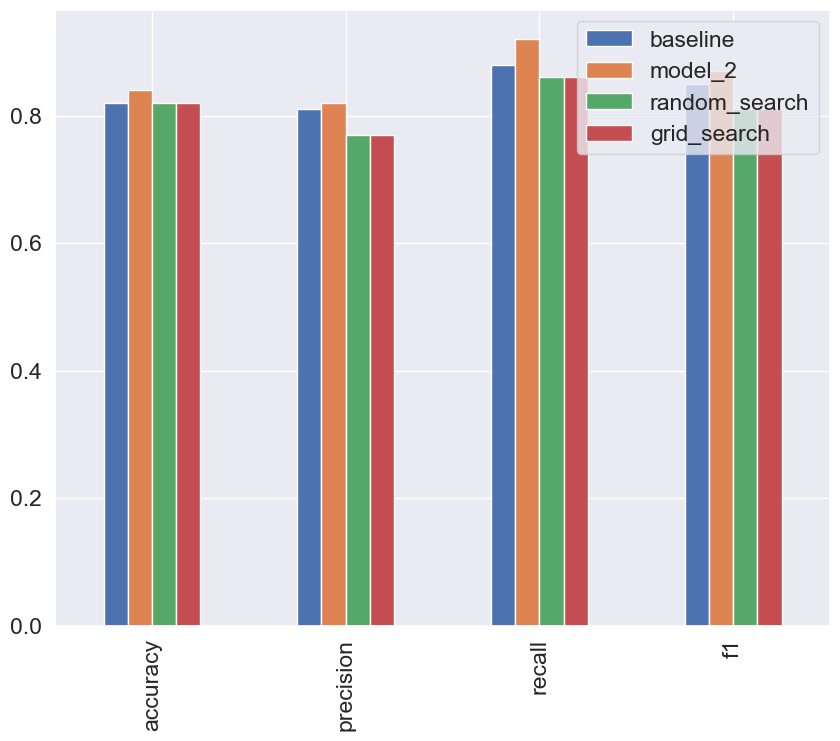

In [118]:
compare_metrics = pd.DataFrame({"baseline": baseline_metrics,
                                "model_2": model_2_metrics,
                                "random_search": rs_metrics,
                                "grid_search": gs_metrics})
compare_metrics.plot.bar(figsize=(10,8))

now we can tune according to our needs

Correlation :- if two attributes (columns) are highly correlated (eg. land size and house size/carpet area are directly related to price, the rise in price is same across the data for per unit increase in land size or house size) then we can remove these columns as they serve no purpose in training the model

Attribute selection :-
1. Backward :- train on all attributes then remove attributes one by one.
2. Forward :- start with one column and keep increasing until accuracy plateaus

## 6. Saveing and Loading a Model

There are 2 ways
1. with python `pickle` module
2. with the `joblib` module

**Pickle**

In [119]:
import pickle

# Save an existing model to file
pickle.dump(gs_model, open("gs_random_forest_model.pkl", "wb"))

In [120]:
# Load a pickle model
loaded_model = pickle.load(open("gs_random_forest_model.pkl", "rb"))

In [121]:
loaded_model.score(X_test,Y_test)

0.819672131147541

In [122]:
gs_model.score(X_test,Y_test)

0.819672131147541

**Joblib**

In [123]:
from joblib import dump, load

# save an existing model to file
dump(gs_model, filename="gs_random_forest_model.joblib")

['gs_random_forest_model.joblib']

In [124]:
# Load a joblib model
loaded_model = load(filename="gs_random_forest_model.joblib")

In [125]:
loaded_model.score(X_test,Y_test)

0.819672131147541

In [126]:
gs_model.score(X_test,Y_test)

0.819672131147541

if our model is large it is better to use joblib as it is more efficient for models fitted with np arrays

# Putting it all together

In [127]:
data = pd.read_csv("data/car-sales-extended-missing-data.csv")
data.head()

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0
2,Honda,White,84714.0,4.0,28343.0
3,Toyota,White,154365.0,4.0,13434.0
4,Nissan,Blue,181577.0,3.0,14043.0


In [128]:
data.dtypes

Make                 str
Colour               str
Odometer (KM)    float64
Doors            float64
Price            float64
dtype: object

In [129]:
data.isna().sum()

Make             49
Colour           50
Odometer (KM)    50
Doors            50
Price            50
dtype: int64

Steps we have to do :-  
1. Fill the missing data
2. Convert the data to numbers
3. Build a model on the data

In [130]:
# All in one cell
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV

np.random.seed(42)

data = pd.read_csv("data/car-sales-extended-missing-data.csv")
data.dropna(subset=["Price"], inplace=True) # removed the missing data

# Define different features and transformer Pipeline
categorical_features = ["Make", "Colour"]
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

door_features = ["Doors"]
door_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value=4))
])


numeric_features = ["Odometer (KM)"]
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean"))
])

# setup the preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", categorical_transformer, categorical_features),
        ("door", door_transformer, door_features),
        ("numeric", numeric_transformer, numeric_features)
    ]
)

# Creating a preprocessing and modelling pipeline
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor())
])

# Split data
X = data.drop("Price", axis=1)
Y = data.Price

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2)

# Fit and score the model
model.fit(X_train,Y_train)
model.score(X_test,Y_test)

0.22188417408787875

In [131]:
# using GridSearchCV or RandomisedSearchCV

pipe_grid = {
    "preprocessor__numeric__imputer__strategy": ["mean", "median"], # this name has to be carefully written based on the names given above
    # this can be thought of as going up a step
    "model__n_estimators": [100,1000],
    "model__max_depth": [None,5],
    "model__max_features": ["sqrt"],
    "model__min_samples_split": [2,4]
}

gs_model = GridSearchCV(model, pipe_grid, cv=5, verbose=2)
gs_model.fit(X_train,Y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_split=2, model__n_estimators=100, preprocessor__numeric__imputer__strategy=mean; total time=   0.3s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_split=2, model__n_estimators=100, preprocessor__numeric__imputer__strategy=mean; total time=   0.3s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_split=2, model__n_estimators=100, preprocessor__numeric__imputer__strategy=mean; total time=   0.3s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_split=2, model__n_estimators=100, preprocessor__numeric__imputer__strategy=mean; total time=   0.3s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_split=2, model__n_estimators=100, preprocessor__numeric__imputer__strategy=mean; total time=   0.2s
[CV] END model__max_depth=None, model__max_features=sq

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...Regressor())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 5], 'model__max_features': ['sqrt'], 'model__min_samples_split': [2, 4], 'model__n_estimators': [100, 1000], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for eac

In [132]:
gs_model.score(X_test,Y_test)

0.2848784564026805